# WSTAD para requisições HTTP: diagnóstico visual

Este notebook reproduz o teste do `main.py`, mas com gráficos para entender melhor o cenário fracamente supervisionado:

- distribuição de requisições por IP/sessão;
- sobreposição de rótulos fracos por IP;
- embeddings semânticos com `all-MiniLM-L6-v2`;
- suspeitos de rótulo fraco por proximidade semântica;
- scores iniciais e perdas do modelo WSTAD.

A leitura correta aqui é diagnóstica. Como os rótulos são fracos, `unsafe` pode conter bot e `bot` pode conter tráfego humano/unsafe.

In [12]:
from pathlib import Path
import collections

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.decomposition import PCA

from main import find_data_file, load_json_events, build_session_key_fn
from http_preprocessing import coerce_mapping, event_to_text, extract_ip, preprocess_http_events
from semantic_features import MINILM_EMBEDDING_DIM, MINILM_FEATURE_DIM, build_minilm_feature_map
from crossbatch_memory_banck import BotDetectionNet, CrossBatchMemoryBank
from mil_functions import mil_loss, contrastive_clustering_loss

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 160)

## 1. Parâmetros do experimento

Troque `DATASET` para `tiktok`, `taboola` ou `outbrain`. Para usar o MiniLM sem tentar acessar a internet, deixe `MINILM_OFFLINE=True` depois que o modelo já estiver em cache.

In [13]:
DATASET = "tiktok"  # "tiktok", "taboola" ou "outbrain"
LIMIT_PER_FILE = 1000

SESSION_MODE = "label-chunk"  # "ip", "ip-hour", "ip-user-agent-hour", "label-chunk"
CHUNK_SIZE = 32
MAX_LEN = 32
TOP_K = 3

FEATURE_MODE = "minilm"  # "hashing" ou "minilm"
MINILM_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
MINILM_OFFLINE = True
EMBEDDING_BATCH_SIZE = 64

UNSAFE_PATH = Path("../..") / "data" / f"{DATASET}-unsafe-10k.json"
BOT_PATH = Path("../..") / "data" / f"{DATASET}-bot-10k.json"

if not UNSAFE_PATH.exists():
    UNSAFE_PATH = find_data_file((f"{DATASET}-unsafe-10k.json", "unsafe-10k.json"))
if not BOT_PATH.exists():
    BOT_PATH = find_data_file((f"{DATASET}-bot-10k.json", "bot-10k.json"))

print("unsafe/human:", UNSAFE_PATH)
print("bot:", BOT_PATH)

unsafe/human: ..\..\data\tiktok-unsafe-10k.json
bot: ..\..\data\tiktok-bot-10k.json


## 2. Carregamento e visã0o geral dos rótulos fracos

In [14]:
unsafe_events = load_json_events(UNSAFE_PATH, decision="unsafe", limit=LIMIT_PER_FILE)
bot_events = load_json_events(BOT_PATH, decision="bot", limit=LIMIT_PER_FILE)
events = unsafe_events + bot_events

rows = []
for event in events:
    headers = coerce_mapping(event.get("headers"))
    request = coerce_mapping(event.get("request"))
    rows.append({
        "weak_label": event.get("_source_decision") or event.get("decision"),
        "decision_raw": event.get("decision"),
        "ip": extract_ip(event),
        "user_agent": headers.get("User-Agent") or headers.get("user-agent") or "",
        "n_headers": len(headers),
        "n_request_params": len(request),
        "request_keys": ", ".join(sorted(map(str, request.keys()))[:12]),
    })

df = pd.DataFrame(rows)
summary = pd.DataFrame({
    "requests": df.groupby("weak_label").size(),
    "unique_ips": df.groupby("weak_label")["ip"].nunique(),
    "unique_user_agents": df.groupby("weak_label")["user_agent"].nunique(),
}).fillna(0).astype(int)

display(summary)
display(df.head(5))

,requests,unique_ips,unique_user_agents
weak_label,,,
bot,1000,914,348
unsafe,1000,876,360


,weak_label,decision_raw,ip,user_agent,n_headers,n_request_params,request_keys
0,unsafe,unsafe,82.5.208.97,"Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/26.4 Mobile/15E148 Safari/604.1",53,5,"sku, src, ttclid, utm_content, utm_medium"
1,unsafe,unsafe,2a02:c7c:4cbb:d500:34ac:fa56:6e95:582d,"Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/26.3 Mobile/15E148 Safari/604.1",53,5,"sku, src, ttclid, utm_content, utm_medium"
2,unsafe,unsafe,81.99.86.64,"Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/26.3 Mobile/15E148 Safari/604.1",54,8,"h1, h2, reengage, sku, src, ttclid, utm_content, utm_medium"
3,unsafe,unsafe,2a0e:1d47:8a8f:e00:8252:3479:323:dae3,"Mozilla/5.0 (Linux; Android 16; SM-S908B Build/BP2A.250605.031.A3) AppleWebKit/537.36 (KHTML, like Gecko) Version/4.0 Chrome/147.0.7727.112 Mobile Safari/53...",61,5,"sku, src, ttclid, utm_content, utm_medium"
4,unsafe,unsafe,2.99.54.233,"Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/26.4 Mobile/15E148 Safari/604.1",53,5,"sku, src, ttclid, utm_content, utm_medium"


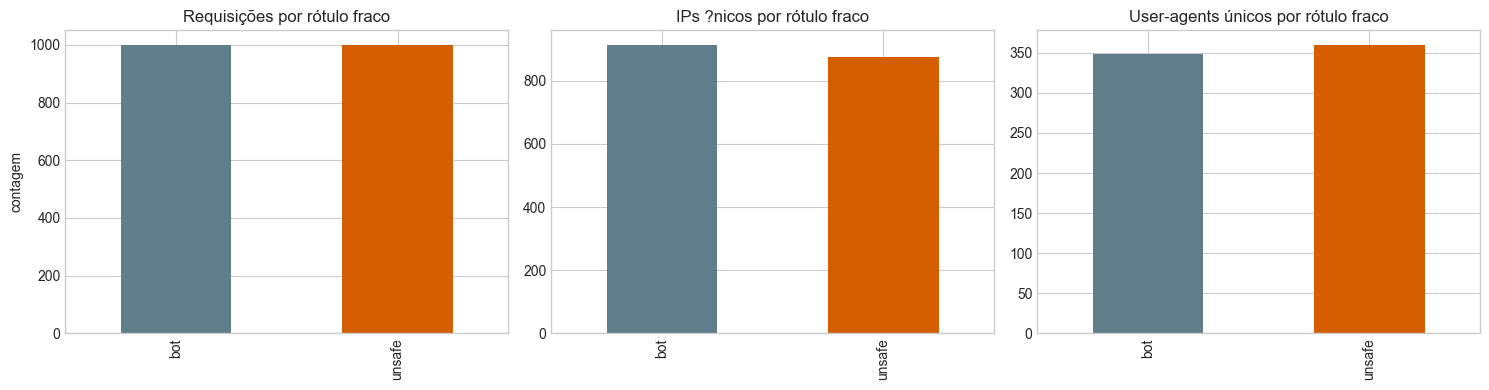

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
summary["requests"].plot(kind="bar", ax=axes[0], color=["#607D8B", "#D55E00"])
axes[0].set_title("Requisições por rótulo fraco")
axes[0].set_xlabel("")
axes[0].set_ylabel("contagem")

summary["unique_ips"].plot(kind="bar", ax=axes[1], color=["#607D8B", "#D55E00"])
axes[1].set_title("IPs únicos por rótulo fraco")
axes[1].set_xlabel("")

summary["unique_user_agents"].plot(kind="bar", ax=axes[2], color=["#607D8B", "#D55E00"])
axes[2].set_title("User-agents únicos por rótulo fraco")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

## 3. Diagnóstico de sessão/bag

No artigo, cada vídeo é uma bag com vários segmentos. Aqui, a bag pode ser IP, IP+hora, IP+user-agent+hora ou chunks rotulados. O gráfico abaixo mostra se a escolha cria sequências longas o bastante para WAGCN/MIL.

,metric,value
0,sessions,64.00
1,mean_len,31.25
2,median_len,32.00
3,p95_len,32.00
4,max_len,32.00
5,single_request_sessions,0.00
6,mixed_label_ips,15.00


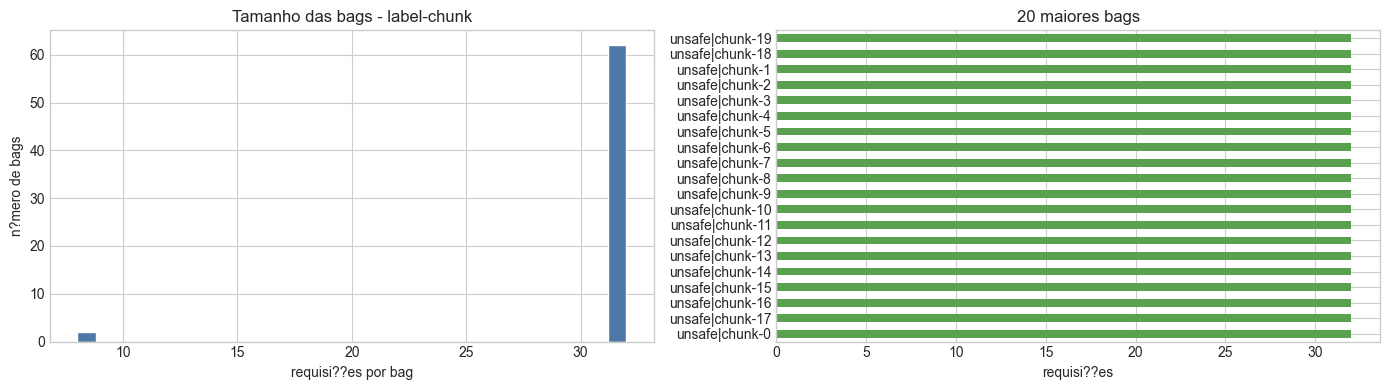

In [ ]:
session_key_fn = build_session_key_fn(SESSION_MODE, CHUNK_SIZE)
session_ids_raw = [session_key_fn(event) for event in events]
session_counts = pd.Series(session_ids_raw).value_counts()

ip_label_counts = df.groupby("ip")["weak_label"].nunique()
mixed_label_ips = int((ip_label_counts > 1).sum())

session_diag = pd.DataFrame({
    "metric": ["sessions", "mean_len", "median_len", "p95_len", "max_len", "single_request_sessions", "mixed_label_ips"],
    "value": [
        len(session_counts),
        session_counts.mean(),
        session_counts.median(),
        session_counts.quantile(0.95),
        session_counts.max(),
        int((session_counts == 1).sum()),
        mixed_label_ips,
    ],
})
display(session_diag)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(session_counts.values, bins=30, color="#4E79A7", edgecolor="white")
axes[0].set_title(f"Tamanho das bags - {SESSION_MODE}")
axes[0].set_xlabel("requisições por bag")
axes[0].set_ylabel("número de bags")

session_counts.head(20).sort_values().plot(kind="barh", ax=axes[1], color="#59A14F")
axes[1].set_title("20 maiores bags")
axes[1].set_xlabel("requisições")
plt.tight_layout()
plt.show()

## 4. Construção das features

- `hashing`: baseline leve com tokens de headers/request + features numéricas.
- `minilm`: embedding semântico `all-MiniLM-L6-v2` de 384 dimensões + 8 features numéricas.

In [17]:
feature_fn = None
effective_feature_dim = 64
feature_map = None

if FEATURE_MODE == "minilm":
    feature_map = build_minilm_feature_map(
        events,
        model_name=MINILM_MODEL,
        batch_size=EMBEDDING_BATCH_SIZE,
        offline=MINILM_OFFLINE,
    )
    feature_fn = lambda event: feature_map[id(event)]
    effective_feature_dim = MINILM_FEATURE_DIM

X, y, mask, session_ids = preprocess_http_events(
    events,
    feature_dim=effective_feature_dim,
    max_len=MAX_LEN,
    session_key_fn=session_key_fn,
    feature_fn=feature_fn,
)

print("X:", tuple(X.shape))
print("y:", tuple(y.shape), "bot bags:", int(y.sum().item()))
print("mask valid requests:", int(mask.sum().item()))
print("feature_dim:", effective_feature_dim)

Batches: 100%|██████████| 32/32 [01:42<00:00,  3.19s/it]


X: (64, 32, 392)
y: (64,) bot bags: 32
mask valid requests: 2000
feature_dim: 392


## 5. Validação semântica dos rótulos fracos

Esta seção roda com `FEATURE_MODE="minilm"`. Ela não mede verdade absoluta. Ela mostra quanto os rótulos fracos concordam com a geometria semântica dos textos HTTP.

In [ ]:
def semantic_diagnostics(events, feature_map, embedding_dim=MINILM_EMBEDDING_DIM, top_k=5):
    labels = torch.tensor([
        1 if str(event.get("_source_decision") or event.get("decision")).lower() in {"bot", "bots"} else 0
        for event in events
    ])
    embeddings = torch.stack([feature_map[id(event)][:embedding_dim] for event in events]).to(torch.float32)
    embeddings = F.normalize(embeddings, dim=1)

    unsafe_center = F.normalize(embeddings[labels == 0].mean(dim=0, keepdim=True), dim=1)
    bot_center = F.normalize(embeddings[labels == 1].mean(dim=0, keepdim=True), dim=1)

    sim_to_unsafe = (embeddings @ unsafe_center.T).squeeze(1)
    sim_to_bot = (embeddings @ bot_center.T).squeeze(1)
    margin = sim_to_bot - sim_to_unsafe
    pred = (margin > 0).long()

    similarity = embeddings @ embeddings.T
    similarity.fill_diagonal_(-2.0)
    k = min(top_k, len(events) - 1)
    nn_idx = torch.topk(similarity, k=k, dim=1).indices
    nn_agreement_by_event = (labels[nn_idx] == labels.unsqueeze(1)).float().mean(dim=1)

    metrics = {
        "centroid_cosine": F.cosine_similarity(unsafe_center, bot_center).item(),
        "centroid_weak_label_agreement": (pred == labels).float().mean().item(),
        f"top_{k}_neighbor_weak_label_agreement": nn_agreement_by_event.mean().item(),
        "unsafe_closer_to_bot": int(((labels == 0) & (margin > 0)).sum().item()),
        "bot_closer_to_unsafe": int(((labels == 1) & (margin < 0)).sum().item()),
    }

    diag = df.copy()
    diag["label_num"] = labels.numpy()
    diag["sim_to_unsafe"] = sim_to_unsafe.numpy()
    diag["sim_to_bot"] = sim_to_bot.numpy()
    diag["semantic_margin_bot_minus_unsafe"] = margin.numpy()
    diag["centroid_prediction"] = np.where(pred.numpy() == 1, "bot", "unsafe")
    diag["nn_label_agreement"] = nn_agreement_by_event.numpy()
    diag["text"] = [event_to_text(event)[:500] for event in events]
    return metrics, diag, embeddings.numpy()

if FEATURE_MODE == "minilm":
    semantic_metrics, semantic_df, semantic_embeddings = semantic_diagnostics(events, feature_map)
    display(pd.DataFrame([semantic_metrics]).T.rename(columns={0: "value"}))
else:
    semantic_metrics, semantic_df, semantic_embeddings = None, None, None
    print("Mude FEATURE_MODE para 'minilm' para rodar a validação semântica.")

,value
centroid_cosine,0.977399
centroid_weak_label_agreement,0.825500
top_5_neighbor_weak_label_agreement,0.848300
unsafe_closer_to_bot,177.000000
bot_closer_to_unsafe,172.000000


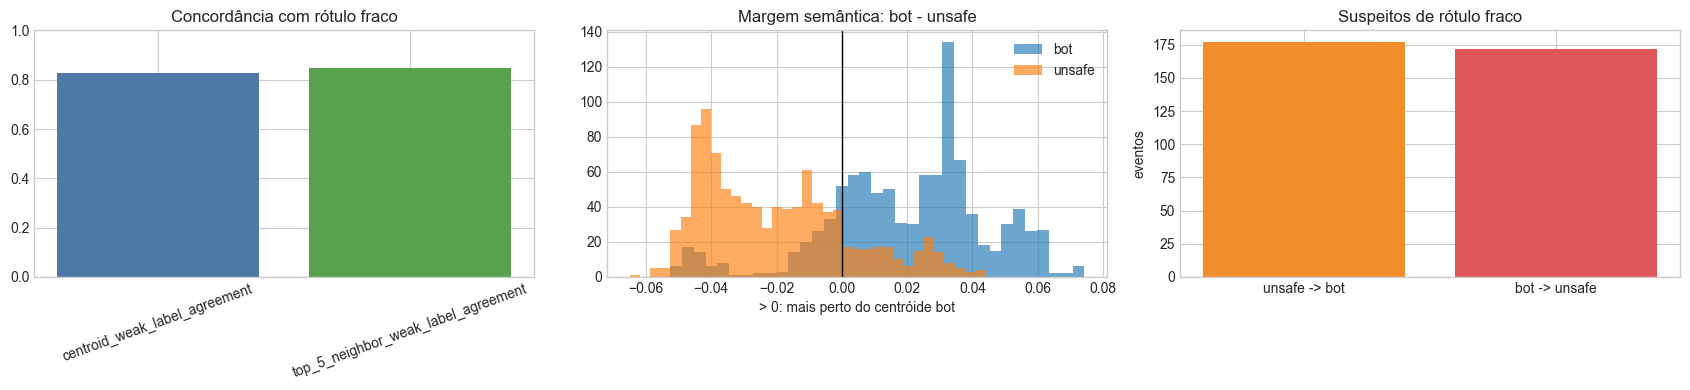

In [31]:
if FEATURE_MODE == "minilm":
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))

    metric_names = ["centroid_weak_label_agreement", "top_5_neighbor_weak_label_agreement"]
    metric_values = [semantic_metrics.get(name, np.nan) for name in metric_names]
    axes[0].bar(metric_names, metric_values, color=["#4E79A7", "#59A14F"])
    axes[0].set_ylim(0, 1)
    axes[0].set_title("Concordância com rótulo fraco")
    axes[0].tick_params(axis="x", rotation=20)

    for label, group in semantic_df.groupby("weak_label"):
        axes[1].hist(group["semantic_margin_bot_minus_unsafe"], bins=35, alpha=0.65, label=label)
    axes[1].axvline(0, color="black", linewidth=1)
    axes[1].set_title("Margem semântica: bot - unsafe")
    axes[1].set_xlabel("> 0: mais perto do centróide bot")
    axes[1].legend()

    suspect_counts = [semantic_metrics["unsafe_closer_to_bot"], semantic_metrics["bot_closer_to_unsafe"]]
    axes[2].bar(["unsafe -> bot", "bot -> unsafe"], suspect_counts, color=["#F28E2B", "#E15759"])
    axes[2].set_title("Suspeitos de rótulo fraco")
    axes[2].set_ylabel("eventos")

    plt.tight_layout()
    plt.show()

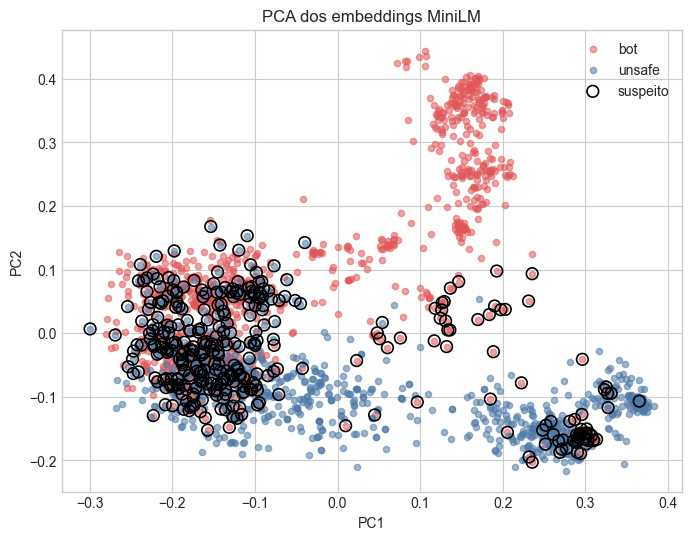

,weak_label,centroid_prediction,ip,semantic_margin_bot_minus_unsafe,nn_label_agreement,text
1047,bot,unsafe,2a00:23c7:5e22:2701:f457:a361:b58d:b302,-0.052621,0.2,"ip: 2a00:23c7:5e22:2701:f457:a361:b58d:b302 | headers: Accept=text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8 Accept-Encoding=gzip, br Accep..."
1017,bot,unsafe,83.105.37.206,-0.051618,1.0,"ip: 83.105.37.206 | headers: Accept=text/html,application/xhtml+xml,application/xml;q=0.9,image/heif,image/avif,image/webp,image/apng,*/*;q=0.8,application/..."
1053,bot,unsafe,81.137.241.127,-0.051104,1.0,"ip: 81.137.241.127 | headers: Accept=text/html,application/xhtml+xml,application/xml;q=0.9,image/heif,image/avif,image/webp,image/apng,*/*;q=0.8,application..."
1060,bot,unsafe,90.250.48.207,-0.050530,0.4,"ip: 90.250.48.207 | headers: Accept=text/html,application/xhtml+xml,application/xml;q=0.9,image/heif,image/avif,image/webp,image/apng,*/*;q=0.8,application/..."
1032,bot,unsafe,86.186.242.107,-0.050526,1.0,"ip: 86.186.242.107 | headers: Accept=text/html,application/xhtml+xml,application/xml;q=0.9,image/heif,image/avif,image/webp,image/apng,*/*;q=0.8,application..."
1046,bot,unsafe,2a00:23c7:5e22:2701:f457:a361:b58d:b302,-0.050367,0.2,"ip: 2a00:23c7:5e22:2701:f457:a361:b58d:b302 | headers: Accept=text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8 Accept-Encoding=gzip, br Accep..."
1013,bot,unsafe,194.207.231.34,-0.048752,0.8,"ip: 194.207.231.34 | headers: Accept=text/html,application/xhtml+xml,application/xml;q=0.9,image/heif,image/avif,image/webp,image/apng,*/*;q=0.8,application..."
1052,bot,unsafe,82.28.25.21,-0.048647,1.0,"ip: 82.28.25.21 | headers: Accept=text/html,application/xhtml+xml,application/xml;q=0.9,image/heif,image/avif,image/webp,image/apng,*/*;q=0.8,application/si..."
1042,bot,unsafe,213.31.7.185,-0.047858,1.0,"ip: 213.31.7.185 | headers: Accept=text/html,application/xhtml+xml,application/xml;q=0.9,image/heif,image/avif,image/webp,image/apng,*/*;q=0.8,application/s..."
1054,bot,unsafe,82.15.12.56,-0.047712,1.0,"ip: 82.15.12.56 | headers: Accept=text/html,application/xhtml+xml,application/xml;q=0.9,image/heif,image/avif,image/webp,image/apng,*/*;q=0.8,application/si..."


In [20]:
if FEATURE_MODE == "minilm":
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(semantic_embeddings)
    plot_df = semantic_df.copy()
    plot_df["pc1"] = coords[:, 0]
    plot_df["pc2"] = coords[:, 1]
    plot_df["suspect"] = plot_df["weak_label"] != plot_df["centroid_prediction"]

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = {"unsafe": "#4E79A7", "bot": "#E15759"}
    for label, group in plot_df.groupby("weak_label"):
        ax.scatter(group["pc1"], group["pc2"], s=20, alpha=0.55, label=label, c=colors.get(label, "gray"))
    suspects = plot_df[plot_df["suspect"]]
    ax.scatter(suspects["pc1"], suspects["pc2"], s=70, facecolors="none", edgecolors="black", linewidths=1.2, label="suspeito")
    ax.set_title("PCA dos embeddings MiniLM")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    plt.show()

    suspect_table = plot_df[plot_df["suspect"]].copy()
    suspect_table["abs_margin"] = suspect_table["semantic_margin_bot_minus_unsafe"].abs()
    display(suspect_table.sort_values("abs_margin", ascending=False)[[
        "weak_label", "centroid_prediction", "ip", "semantic_margin_bot_minus_unsafe", "nn_label_agreement", "text"
    ]].head(15))

## 6. Forward do modelo WSTAD e scores iniciais

Aqui ainda não há treino completo. Os scores e losses mostram se o pipeline está numericamente saudável e comparável entre `hashing` e `minilm`.

In [21]:
model = BotDetectionNet(feature_dim=effective_feature_dim, embedding_dim=32)
memory_bank = CrossBatchMemoryBank(feature_dim=32)

scores, features = model(X, mask=mask)
loss_mil = mil_loss(scores, y, k=TOP_K, mask=mask)
loss_contrastive = contrastive_clustering_loss(features, scores, y, memory_bank, k=TOP_K, mask=mask)
loss_total = loss_mil + loss_contrastive

valid_scores = scores[mask].detach().squeeze(-1).numpy()
score_rows = []
for bag_idx, session_id in enumerate(session_ids):
    valid_len = int(mask[bag_idx].sum().item())
    for t in range(valid_len):
        score_rows.append({
            "session_id": session_id,
            "bag_label": "bot" if y[bag_idx].item() == 1 else "unsafe",
            "t": t,
            "score": float(scores[bag_idx, t, 0].detach().item()),
        })
score_df = pd.DataFrame(score_rows)

loss_df = pd.DataFrame({
    "loss": ["MIL", "contrastive", "total"],
    "value": [loss_mil.item(), loss_contrastive.item(), loss_total.item()],
})
display(loss_df)
print("score mean/min/max:", valid_scores.mean(), valid_scores.min(), valid_scores.max())

,loss,value
0,MIL,0.252040
1,contrastive,0.693147
2,total,0.945187


score mean/min/max: 0.54586905 0.54051375 0.5483565


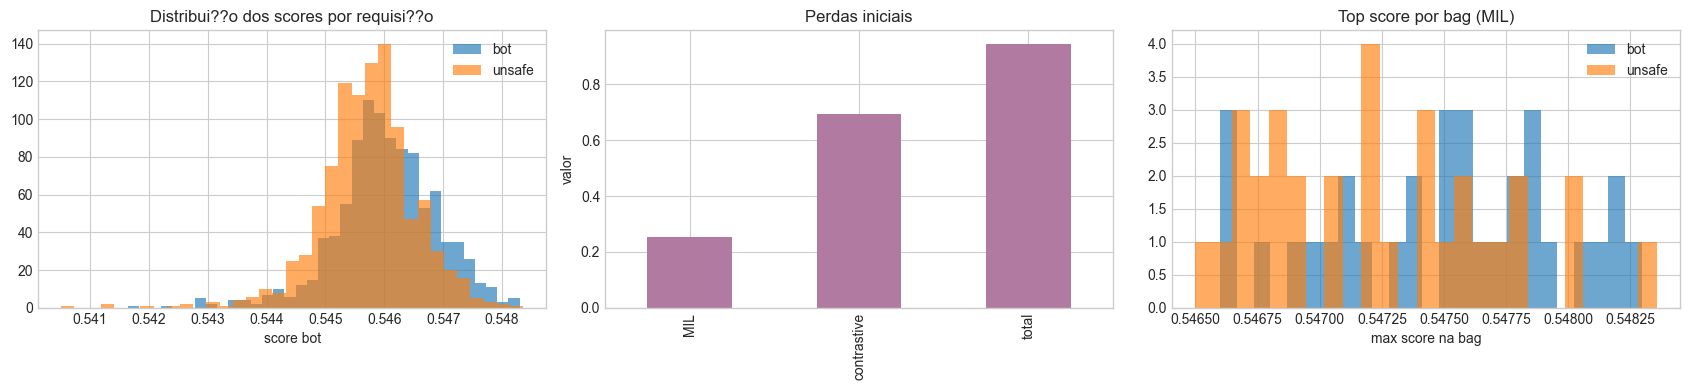

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

for label, group in score_df.groupby("bag_label"):
    axes[0].hist(group["score"], bins=35, alpha=0.65, label=label)
axes[0].set_title("Distribuição dos scores por requisição")
axes[0].set_xlabel("score bot")
axes[0].legend()

loss_df.plot(kind="bar", x="loss", y="value", legend=False, ax=axes[1], color="#B07AA1")
axes[1].set_title("Perdas iniciais")
axes[1].set_xlabel("")
axes[1].set_ylabel("valor")

score_by_bag = score_df.groupby(["session_id", "bag_label"])["score"].max().reset_index()
for label, group in score_by_bag.groupby("bag_label"):
    axes[2].hist(group["score"], bins=25, alpha=0.65, label=label)
axes[2].set_title("Top score por bag (MIL)")
axes[2].set_xlabel("max score na bag")
axes[2].legend()

plt.tight_layout()
plt.show()

## 7. Leitura rápida

- Se `single_request_sessions` for alto no modo `ip`, o problema não está parecido com vídeo/anomalia temporal; prefira `label-chunk` para validar a arquitetura.
- Se `centroid_cosine` ficar muito perto de 1, os dois grupos têm semântica global parecida.
- Se `top-5 neighbor agreement` for alto, ainda há sinal local útil.
- Suspeitos `unsafe -> bot` e `bot -> unsafe` são candidatos naturais para revisão de rótulo fraco ou treinamento robusto a ruído.

## 8. Comparação dos modos de bag/sessão

Esta seção compara as formas de criar bags para adaptar o artigo ao tráfego HTTP.

- `ip`: entidade real, mas pode gerar muitas bags com uma única requisição.
- `ip-hour`: força janela temporal, útil quando IP reaparece ao longo do tempo.
- `ip-user-agent-hour`: reduz mistura por NAT/proxy, mas costuma fragmentar ainda mais.
- `label-chunk`: bag artificial por rótulo fraco, útil para validar MIL/WSTAD quando não há sessão real longa.

A imagem mais importante aqui é a distribuição de tamanho das bags: se quase tudo tem tamanho 1, a parte temporal/grafo do artigo fica pouco explorada.

,mode,bags,mean_len,median_len,p95_len,max_len,singletons,singleton_rate
0,ip,1775,1.126761,1.0,2.0,23,1615,0.909859
1,ip-hour,1816,1.101322,1.0,2.0,23,1679,0.924559
2,ip-user-agent-hour,1837,1.088732,1.0,2.0,23,1718,0.935220
3,label-chunk,64,31.250000,32.0,32.0,32,0,0.000000


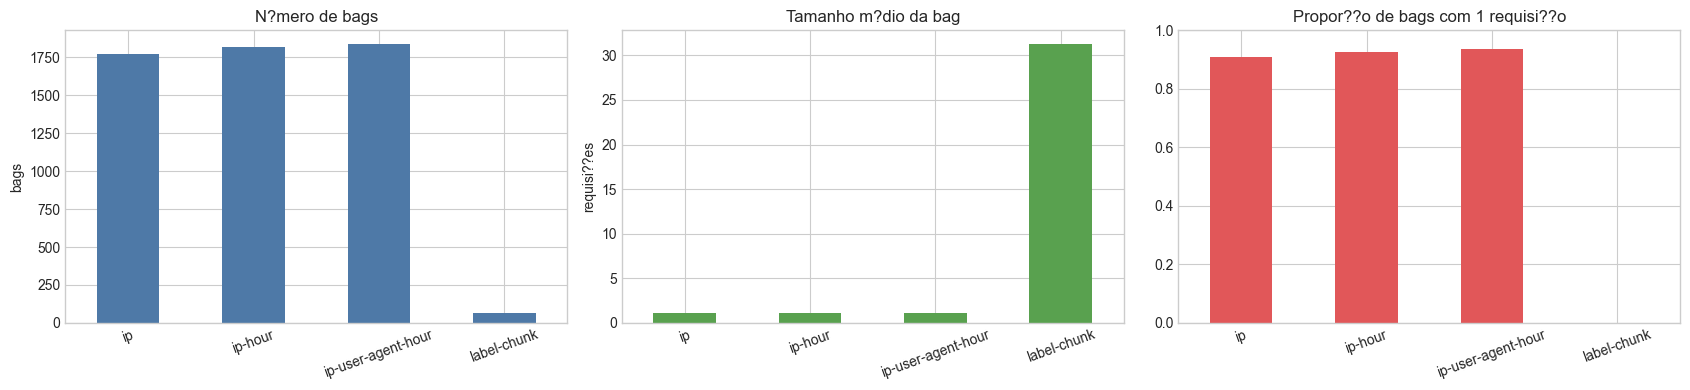

In [ ]:
def bag_mode_summary(events, modes=("ip", "ip-hour", "ip-user-agent-hour", "label-chunk"), chunk_size=CHUNK_SIZE):
    rows = []
    for mode in modes:
        key_fn = build_session_key_fn(mode, chunk_size)
        keys = [key_fn(event) for event in events]
        counts = pd.Series(keys).value_counts()
        rows.append({
            "mode": mode,
            "bags": len(counts),
            "mean_len": counts.mean(),
            "median_len": counts.median(),
            "p95_len": counts.quantile(0.95),
            "max_len": counts.max(),
            "singletons": int((counts == 1).sum()),
            "singleton_rate": float((counts == 1).mean()),
        })
    return pd.DataFrame(rows)

bag_modes_df = bag_mode_summary(events)
display(bag_modes_df)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
bag_modes_df.plot(kind="bar", x="mode", y="bags", ax=axes[0], legend=False, color="#4E79A7")
axes[0].set_title("Número de bags")
axes[0].set_xlabel("")
axes[0].set_ylabel("bags")

bag_modes_df.plot(kind="bar", x="mode", y="mean_len", ax=axes[1], legend=False, color="#59A14F")
axes[1].set_title("Tamanho médio da bag")
axes[1].set_xlabel("")
axes[1].set_ylabel("requisições")

bag_modes_df.plot(kind="bar", x="mode", y="singleton_rate", ax=axes[2], legend=False, color="#E15759")
axes[2].set_title("Proporção de bags com 1 requisição")
axes[2].set_xlabel("")
axes[2].set_ylim(0, 1)

for ax in axes:
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### Como interpretar a imagem dos modos de bag

Para aproximar o artigo, queremos bags com múltiplas instâncias. Se `singleton_rate` for alto em `ip`, o modelo deixa de se parecer com detecção temporal em vídeo e vira quase uma classificação por requisição.

Nesse cenário, `label-chunk` não representa uma sessão real, mas cria bags suficientemente longas para testar a hipótese MIL/contrastive do artigo sob rótulos fracos.

## 9. Comparação: MIL puro vs MIL + contrastive clustering

Esta seção treina duas variantes com a mesma entrada `X`:

- `MIL puro`: usa apenas a perda MIL, que força bags bot a terem top-k scores altos e bags unsafe a terem scores baixos.
- `MIL + contrastive`: soma a perda MIL com a perda contrastiva, tentando aproximar embeddings da mesma classe fraca e afastar da classe oposta.

Como os rótulos são fracos, `AUC` e separação de score aqui medem concordância com rótulos fracos, não verdade absoluta.

In [24]:
from sklearn.metrics import roc_auc_score
import torch.optim as optim


def bag_scores_from_request_scores(scores, mask, k=TOP_K):
    bag_scores = []
    for i in range(scores.shape[0]):
        valid_scores = scores[i, mask[i], 0]
        topk = torch.topk(valid_scores, min(k, valid_scores.shape[0])).values
        bag_scores.append(topk.mean())
    return torch.stack(bag_scores)


def update_memory_from_topk(memory_bank, features, scores, labels, mask, k=TOP_K):
    normal_features = []
    abnormal_features = []
    for i in range(features.shape[0]):
        valid_scores = scores[i, mask[i], 0]
        valid_features = features[i, mask[i], :]
        topk_idx = torch.topk(valid_scores, min(k, valid_scores.shape[0])).indices
        selected = valid_features[topk_idx].detach()
        if labels[i].item() == 1:
            abnormal_features.append(selected)
        else:
            normal_features.append(selected)

    normal_tensor = torch.cat(normal_features, dim=0) if normal_features else features.new_empty((0, features.shape[-1]))
    abnormal_tensor = torch.cat(abnormal_features, dim=0) if abnormal_features else features.new_empty((0, features.shape[-1]))
    memory_bank.update(normal_tensor.cpu(), abnormal_tensor.cpu())


def train_wstad_variant(loss_mode, epochs=30, lr=1e-3, contrastive_weight=1.0):
    torch.manual_seed(42)
    model = BotDetectionNet(feature_dim=effective_feature_dim, embedding_dim=32)
    memory_bank = CrossBatchMemoryBank(feature_dim=32)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        scores, features = model(X, mask=mask)

        loss_m = mil_loss(scores, y, k=TOP_K, mask=mask)
        if loss_mode == "mil_contrastive":
            update_memory_from_topk(memory_bank, features, scores, y, mask, k=TOP_K)
            loss_c = contrastive_clustering_loss(features, scores, y, memory_bank, k=TOP_K, mask=mask)
            loss = loss_m + contrastive_weight * loss_c
        else:
            loss_c = torch.tensor(0.0)
            loss = loss_m

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            bag_scores = bag_scores_from_request_scores(scores, mask, k=TOP_K)
            labels_np = y.cpu().numpy()
            bag_scores_np = bag_scores.cpu().numpy()
            try:
                auc = roc_auc_score(labels_np, bag_scores_np)
            except ValueError:
                auc = np.nan
            unsafe_mean = bag_scores[y == 0].mean().item() if (y == 0).any() else np.nan
            bot_mean = bag_scores[y == 1].mean().item() if (y == 1).any() else np.nan

        history.append({
            "epoch": epoch,
            "variant": "MIL puro" if loss_mode == "mil" else "MIL + contrastive",
            "mil_loss": loss_m.item(),
            "contrastive_loss": loss_c.item(),
            "total_loss": loss.item(),
            "weak_label_auc": auc,
            "unsafe_bag_score_mean": unsafe_mean,
            "bot_bag_score_mean": bot_mean,
            "score_gap_bot_minus_unsafe": bot_mean - unsafe_mean,
        })

    model.eval()
    with torch.no_grad():
        final_scores, final_features = model(X, mask=mask)
        final_bag_scores = bag_scores_from_request_scores(final_scores, mask, k=TOP_K).cpu().numpy()

    return pd.DataFrame(history), final_bag_scores, model

EPOCHS = 30
mil_history, mil_final_bag_scores, mil_model = train_wstad_variant("mil", epochs=EPOCHS)
combined_history, combined_final_bag_scores, combined_model = train_wstad_variant("mil_contrastive", epochs=EPOCHS)
comparison_history = pd.concat([mil_history, combined_history], ignore_index=True)

final_metrics = comparison_history.sort_values("epoch").groupby("variant").tail(1).reset_index(drop=True)
display(final_metrics)

,epoch,variant,mil_loss,contrastive_loss,total_loss,weak_label_auc,unsafe_bag_score_mean,bot_bag_score_mean,score_gap_bot_minus_unsafe
0,30,MIL puro,0.035649,0.000000,0.035649,1.000000,0.150266,0.828280,0.678014
1,30,MIL + contrastive,0.248623,0.075966,0.324589,0.999023,0.512376,0.515525,0.003149


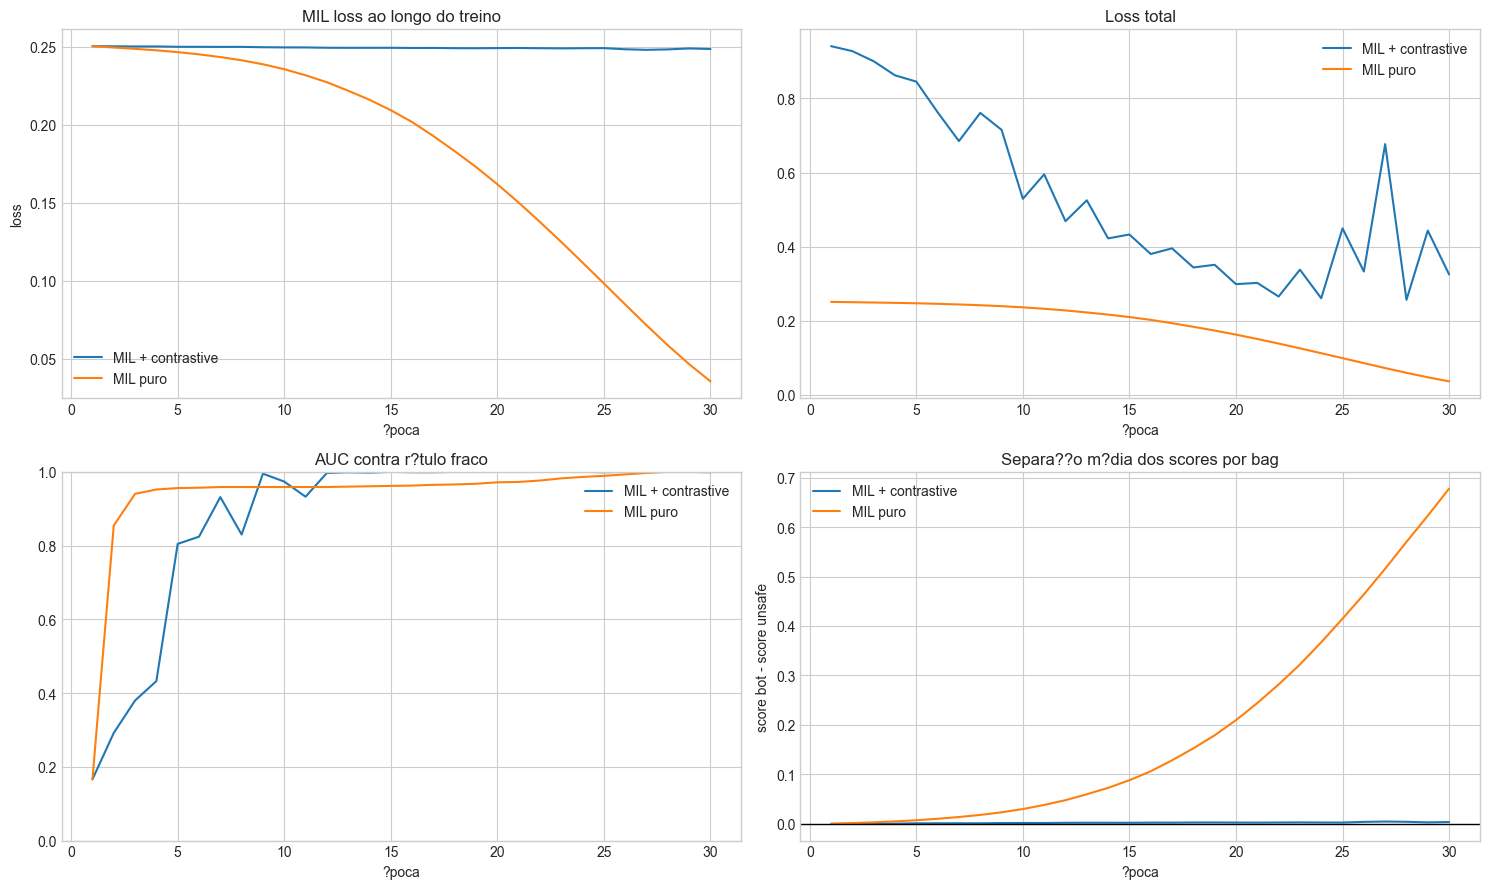

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for variant, group in comparison_history.groupby("variant"):
    axes[0, 0].plot(group["epoch"], group["mil_loss"], label=variant)
axes[0, 0].set_title("MIL loss ao longo do treino")
axes[0, 0].set_xlabel("Época")
axes[0, 0].set_ylabel("loss")
axes[0, 0].legend()

for variant, group in comparison_history.groupby("variant"):
    axes[0, 1].plot(group["epoch"], group["total_loss"], label=variant)
axes[0, 1].set_title("Loss total")
axes[0, 1].set_xlabel("Época")
axes[0, 1].legend()

for variant, group in comparison_history.groupby("variant"):
    axes[1, 0].plot(group["epoch"], group["weak_label_auc"], label=variant)
axes[1, 0].set_title("AUC contra rótulo fraco")
axes[1, 0].set_xlabel("Época")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()

for variant, group in comparison_history.groupby("variant"):
    axes[1, 1].plot(group["epoch"], group["score_gap_bot_minus_unsafe"], label=variant)
axes[1, 1].axhline(0, color="black", linewidth=1)
axes[1, 1].set_title("Separação média dos scores por bag")
axes[1, 1].set_xlabel("Época")
axes[1, 1].set_ylabel("score bot - score unsafe")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

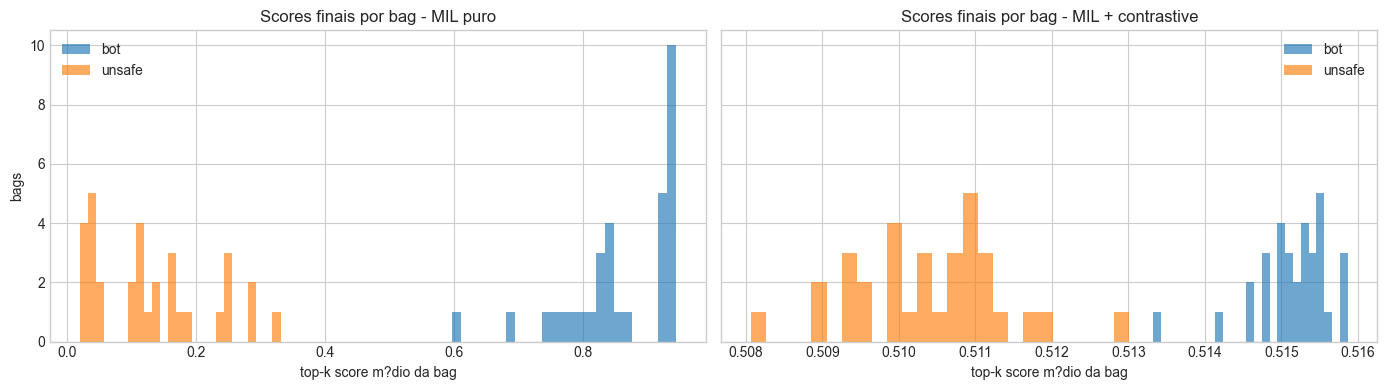

MIL puro                                                    \
              count      mean       std       min       25%       50%   
weak_label                                                              
bot            32.0  0.860567  0.086735  0.597726  0.819251  0.861819   
unsafe         32.0  0.131175  0.091521  0.020214  0.039435  0.116772   

                               MIL + contrastive                      \
                 75%       max             count      mean       std   
weak_label                                                             
bot         0.933812  0.944850              32.0  0.515154  0.000506   
unsafe      0.174149  0.331349              32.0  0.510407  0.000965   

                                                              
                 min       25%       50%       75%       max  
weak_label                                                    
bot         0.513320  0.514985  0.515249  0.515480  0.515867  
unsafe      0.508067  0.509812  0.510458  0.510935  0.513004

In [ ]:
final_score_df = pd.DataFrame({
    "weak_label": np.where(y.cpu().numpy() == 1, "bot", "unsafe"),
    "MIL puro": mil_final_bag_scores,
    "MIL + contrastive": combined_final_bag_scores,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, variant in zip(axes, ["MIL puro", "MIL + contrastive"]):
    for label, group in final_score_df.groupby("weak_label"):
        ax.hist(group[variant], bins=25, alpha=0.65, label=label)
    ax.set_title(f"Scores finais por bag - {variant}")
    ax.set_xlabel("top-k score médio da bag")
    ax.legend()
axes[0].set_ylabel("bags")
plt.tight_layout()
plt.show()

display(final_score_df.groupby("weak_label")[["MIL puro", "MIL + contrastive"]].describe())

### Como interpretar a comparação MIL vs MIL + contrastive

- Se `MIL loss` cai nos dois modelos, ambos estão aprendendo a satisfazer o rótulo fraco da bag.
- Se `MIL + contrastive` melhora `score_gap_bot_minus_unsafe` ou `AUC` contra rótulo fraco, a estrutura semântica/embedding está ajudando.
- Se o contrastive não melhora, há trâs hipóteses fortes: rótulos fracos muito ruidosos, centróides globais muito parecidos, ou memória/centros ainda simples demais.
- No seu resultado semântico, `centroid_cosine` perto de `0.98` sugere que a separação global é difícil; por isso, o contrastive pode precisar de melhorias como pseudo-labels, amostragem por vizinhos, pesos menores ou centers por cluster em vez de um único centro unsafe/bot.

Para uma seção experimental do trabalho, recomendo reportar:

1. tabela dos modos de bag;
2. validação semântica MiniLM;
3. curva `MIL puro` vs `MIL + contrastive`;
4. histograma final dos scores por bag;
5. ressalva explícita de que as métricas usam rótulos fracos, não ground truth limpo.